Temperatura óptima: 30793.74 K
Potencia máxima: 3.514e+08 W/m^2


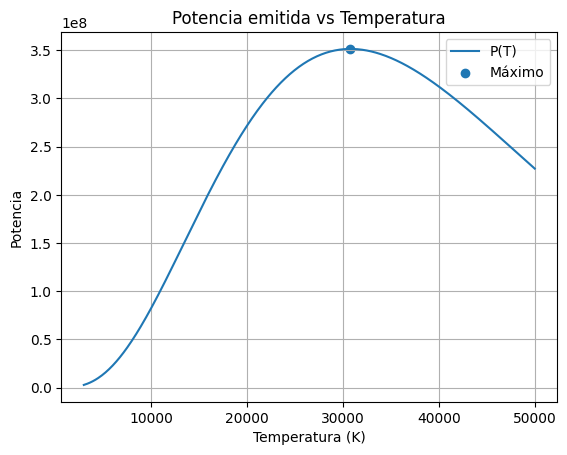

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
sigma = 5.67e-8
T0 = 10000

# Función P(T)
def P(T):
    return sigma * T**4 * np.exp(-T/T0) * (1 - np.exp(-5000/T))

# Para minimizar (negativo)
def f(T):
    return -P(T)

# Sección áurea
def golden_section(a, b, tol=50):
    gr = (np.sqrt(5) + 1) / 2  # razón áurea

    c = b - (b - a) / gr
    d = a + (b - a) / gr

    while abs(b - a) > tol:
        if f(c) < f(d):
            b = d
        else:
            a = c

        c = b - (b - a) / gr
        d = a + (b - a) / gr

    return (a + b) / 2

# Intervalo
a = 3000
b = 50000

# Encontrar máximo
T_opt = golden_section(a, b, tol=50)
P_opt = P(T_opt)

print(f"Temperatura óptima: {T_opt:.2f} K")
print(f"Potencia máxima: {P_opt:.3e} W/m^2")

# Graficar
T_vals = np.linspace(3000, 50000, 500)
P_vals = P(T_vals)

plt.figure()
plt.plot(T_vals, P_vals, label="P(T)")
plt.scatter(T_opt, P_opt, label="Máximo", marker='o')
plt.xlabel("Temperatura (K)")
plt.ylabel("Potencia")
plt.title("Potencia emitida vs Temperatura")
plt.legend()
plt.grid()

plt.show()